# rnns-jax quickstart

Train a recurrent model on your own sequences in a few lines:

1. Put your data in a table (one row per time step).
2. Cut it into windows with `windows_from_frame`.
3. Train with `fit`.
4. Save, load and swap models.

Install the library first: `uv add git+https://github.com/mkeriy/<repo>.git` or `pip install git+...`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from flax import nnx

from rnns_jax import GRU, LSTM, TrainConfig, fit, load_model, make_windows, save_model, windows_from_frame

/Users/damimilko/quant/competitions/rnns-jax/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

Synthetic data: 30 independent sequences of 400 steps. Each one has two noisy sine-like features with its own frequency.
The table has one row per time step: a sequence id plus the feature columns. Your own data should look the same.

In [2]:
rng = np.random.default_rng(0)
frames = []
for seq_id in range(30):
    t = np.arange(400) * 0.1
    freq = rng.uniform(0.5, 1.5)
    frames.append(pl.DataFrame({
        "seq_id": seq_id,
        "step": np.arange(400),
        "x1": np.sin(freq * t) + 0.05 * rng.normal(size=400),
        "x2": np.cos(0.5 * freq * t) + 0.05 * rng.normal(size=400),
    }))
df = pl.concat(frames)
df.head()

seq_id,step,x1,x2
i32,i64,f64,f64
0,0,-0.006605,1.029177
0,1,0.145473,0.926458
0,2,0.230683,1.099484
0,3,0.30773,0.91839
0,4,0.457349,1.020248


## 2. Windows

Split **by sequence** before windowing (24 for training, 6 for validation), so no validation rows leak into training.
Then each window of 50 steps becomes one sample, and the target is the next step of both features.

`X` is a lazy `WindowView`: it behaves like an `(N, 50, 2)` array but only copies the rows a batch needs.

In [3]:
features = ["x1", "x2"]
train_df = df.filter(pl.col("seq_id") < 24)
val_df = df.filter(pl.col("seq_id") >= 24)

X_train, y_train = windows_from_frame(train_df, features, id_col="seq_id", window=50)
X_val, y_val = windows_from_frame(val_df, features, id_col="seq_id", window=50)
print("train", X_train.shape, y_train.shape, "| val", X_val.shape, y_val.shape)

train (8400, 50, 2) (8400, 2) | val (2100, 50, 2) (2100, 2)


## 3. Model

`in_ftrs` = number of input features, `out_ftrs` = number of target columns.
`fit` stops with a clear error if they don't match the data.

In [4]:
model = GRU(rngs=nnx.Rngs(0), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1)

## 4. Train

`TrainConfig` holds the optimizer, learning rate (or a scheduler), batch size and epochs.
Validation runs at the end of each epoch. Set `log_dir` to also write TensorBoard logs.

In [5]:
config = TrainConfig(epochs=5, batch_size=64, lr=3e-3)
model, history = fit(model, X_train, y_train, X_val, y_val, config)

epoch 1/5:   0%|          | 0/131 [00:00<?, ?it/s]

epoch 1/5:   1%|          | 1/131 [00:00<00:44,  2.95it/s]

epoch 1/5:   1%|          | 1/131 [00:00<00:44,  2.95it/s, loss=0.0638]

epoch 1/5:  38%|███▊      | 50/131 [00:00<00:00, 113.12it/s, loss=0.0638]

epoch 1/5:  38%|███▊      | 50/131 [00:00<00:00, 113.12it/s, loss=0.0346]

...

epoch 5/5:  20%|█▉        | 26/131 [00:00<00:00, 253.95it/s, loss=0.00381]

epoch 5/5:  58%|█████▊    | 76/131 [00:00<00:00, 260.19it/s, loss=0.00381]

epoch 5/5:  58%|█████▊    | 76/131 [00:00<00:00, 260.19it/s, loss=0.00387]

epoch 5/5:  96%|█████████▌| 126/131 [00:00<00:00, 258.18it/s, loss=0.00387]

epoch 5/5: 100%|██████████| 131/131 [00:00<00:00, 265.52it/s, loss=0.00387]

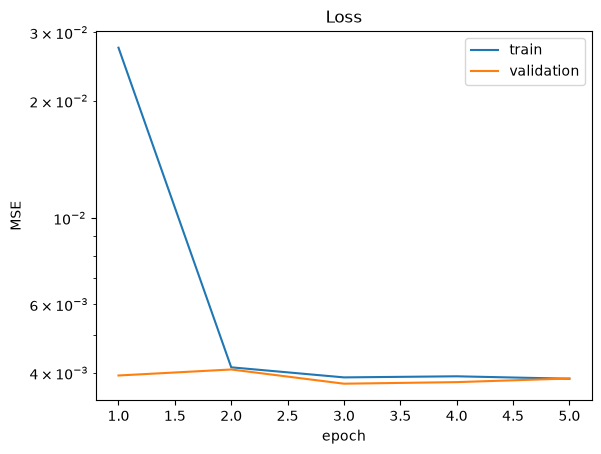

In [6]:
epochs = range(1, config.epochs + 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend(); plt.title("Loss")
plt.show()

## 5. Predict

`model(X)` returns `(predictions, state)`. Here: one-step-ahead predictions over a whole validation sequence.

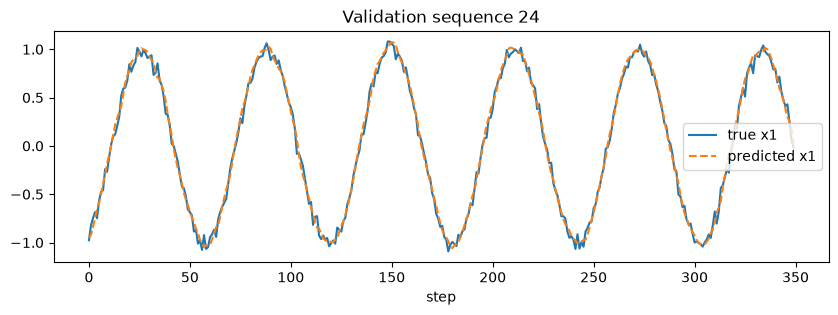

In [7]:
seq = val_df.filter(pl.col("seq_id") == 24).select(features).to_numpy()
X_seq, y_seq = make_windows(seq, window=50)
preds, _ = model(np.asarray(X_seq))

plt.figure(figsize=(10, 3))
plt.plot(y_seq[:, 0], label="true x1")
plt.plot(np.asarray(preds)[:, 0], "--", label="predicted x1")
plt.xlabel("step"); plt.legend(); plt.title("Validation sequence 24")
plt.show()

## 6. Save and load

`save_model` writes the weights to a folder. To load, build a model with the **same arguments** and pass it to `load_model`.

In [8]:
save_model(model, "checkpoints/gru")

restored = load_model(
    GRU(rngs=nnx.Rngs(1), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1),
    "checkpoints/gru",
)
restored_preds, _ = restored(np.asarray(X_seq))
print("max difference after reload:", float(np.abs(np.asarray(restored_preds) - np.asarray(preds)).max()))

max difference after reload: 0.0


## 7. Swap the model

All models share the same interface, so trying another architecture is a one-line change.

In [9]:
lstm = LSTM(rngs=nnx.Rngs(0), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1)
lstm, lstm_history = fit(lstm, X_train, y_train, X_val, y_val, config)
print(f"final val loss  GRU: {history['val_loss'][-1]:.4f}  LSTM: {lstm_history['val_loss'][-1]:.4f}")

epoch 1/5:   0%|          | 0/131 [00:00<?, ?it/s]

epoch 1/5:   1%|          | 1/131 [00:00<00:40,  3.22it/s]

epoch 1/5:   1%|          | 1/131 [00:00<00:40,  3.22it/s, loss=0.0708]

epoch 1/5:  38%|███▊      | 50/131 [00:00<00:00, 104.47it/s, loss=0.0708]

epoch 1/5:  38%|███▊      | 50/131 [00:00<00:00, 104.47it/s, loss=0.0383]

...

epoch 5/5:  58%|█████▊    | 76/131 [00:00<00:00, 191.68it/s, loss=0.00394]

epoch 5/5:  58%|█████▊    | 76/131 [00:00<00:00, 191.68it/s, loss=0.004]  

epoch 5/5:  96%|█████████▌| 126/131 [00:00<00:00, 191.85it/s, loss=0.004]

epoch 5/5: 100%|██████████| 131/131 [00:00<00:00, 197.98it/s, loss=0.004]

final val loss  GRU: 0.0039  LSTM: 0.0041
